 # IMPORT ALL LIBRARIES

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier

# LOADING DATASET

In [178]:
df = pd.read_excel(
    "Telco_customer_churn[1].xlsx",
    engine = "openpyxl"
)

# FIRST FIVE ROWS

In [180]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## DATASET SHAPE

In [182]:
df.shape

(7043, 33)

In [183]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

# DATASET INFORMATION

In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

# STATISTICAL SUMMARY

In [187]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


# MISSING VALUE ANALYSIS

In [189]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

# DATA VISUALIZATION

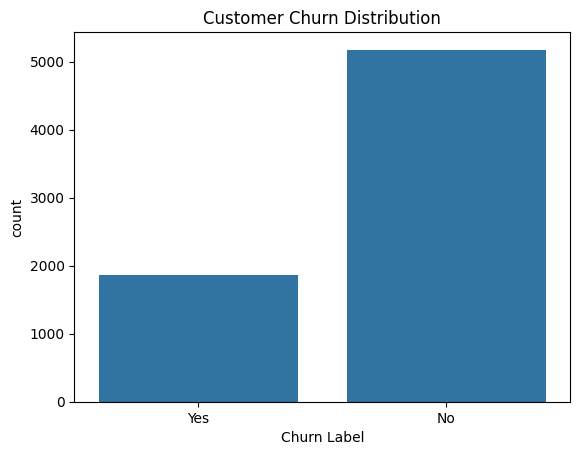

In [191]:
sns.countplot(x = 'Churn Label', data = df)
plt.title("Customer Churn Distribution")
plt.show()

# CHURN PERCENTAGE ANALYSIS

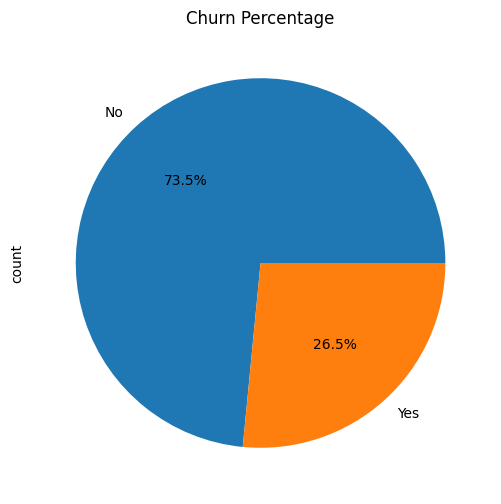

In [193]:
df['Churn Label'].value_counts().plot.pie(
    autopct = '%1.1f%%',
    figsize = (6,6)
)
plt.title("Churn Percentage")
plt.show()

# 
CONTRACT VS CHURN

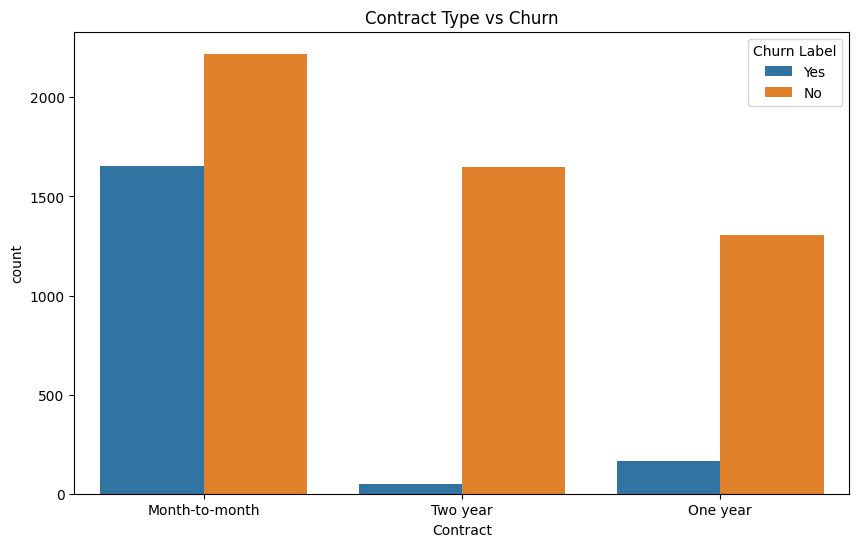

In [195]:
plt.figure(figsize = (10,6))
sns.countplot(
    x = 'Contract',
    hue = 'Churn Label',
    data = df
)
plt.title("Contract Type vs Churn")
plt.show()


# TENURE VS CHURN

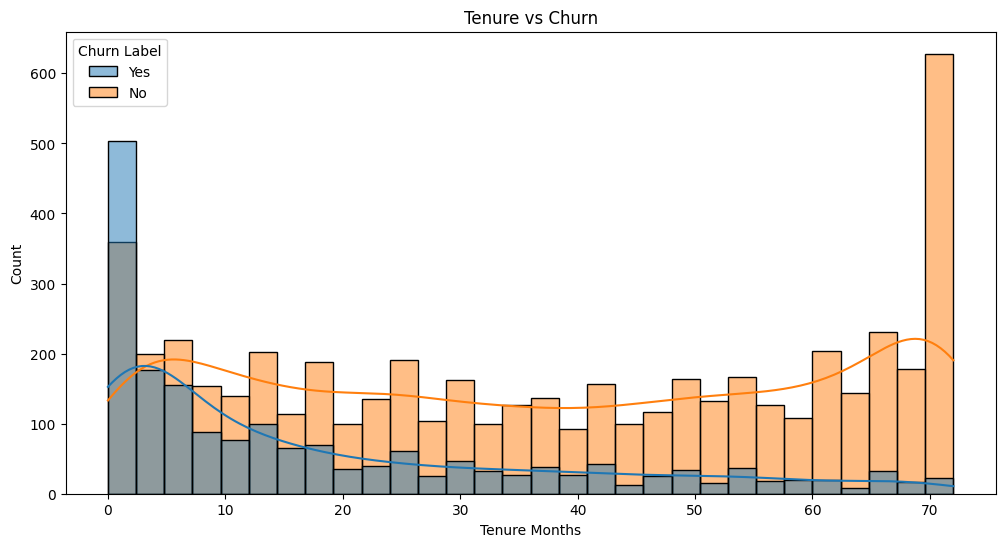

In [197]:
plt.figure(figsize = (12,6))
sns.histplot(
    data = df,
    x =  'Tenure Months',
    hue = 'Churn Label',
    bins = 30,
    kde = True
)
plt.title("Tenure vs Churn")
plt.show()

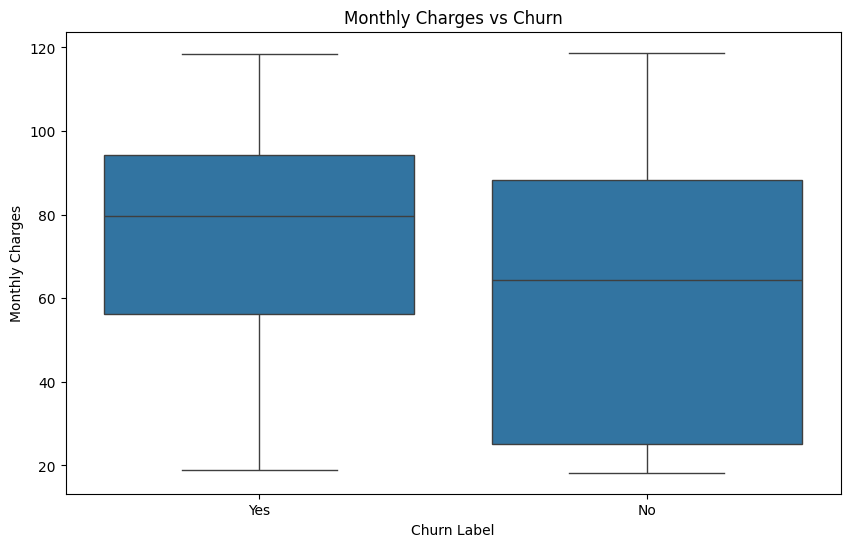

In [198]:
plt.figure(figsize = (10,6))
sns.boxplot(
    x = 'Churn Label',
    y = 'Monthly Charges',
    data = df
)
plt.title("Monthly Charges vs Churn")
plt.show()

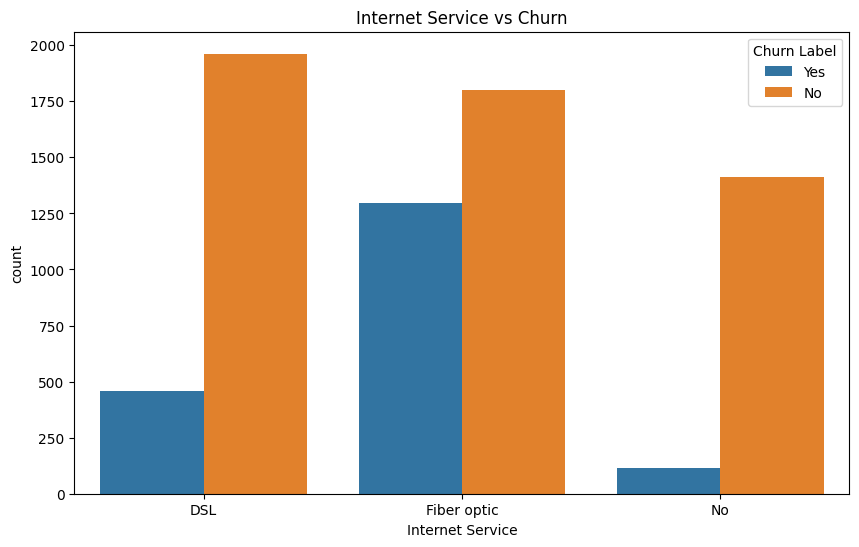

In [199]:
plt.figure(figsize = (10,6))
sns.countplot(
     x = 'Internet Service',
    hue = 'Churn Label',
    data = df
)
plt.title("Internet Service vs Churn")
plt.show()

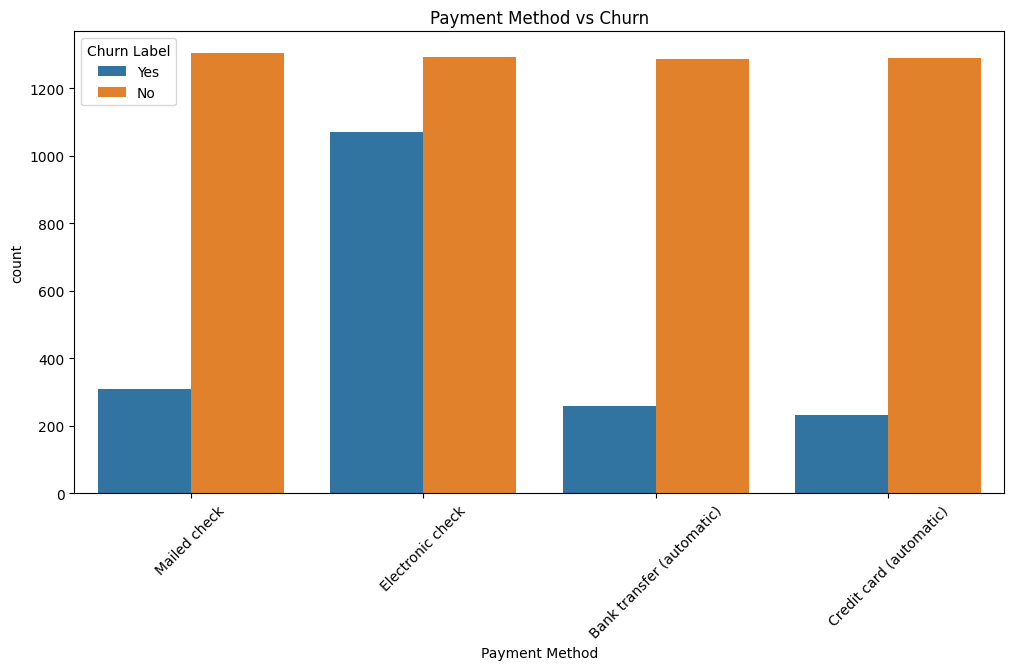

In [200]:
plt.figure(figsize = (12,6))
sns.countplot(
    x = 'Payment Method',
    hue = 'Churn Label',
    data = df
)
plt.xticks(rotation = 45)
plt.title("Payment Method vs Churn")
plt.show()

# LABEL ENCODING CATEGORICAL FEATURE

In [202]:
le = LabelEncoder()
for col in df.select_dtypes(include = 'object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

# CORRELATION HEAT MAP

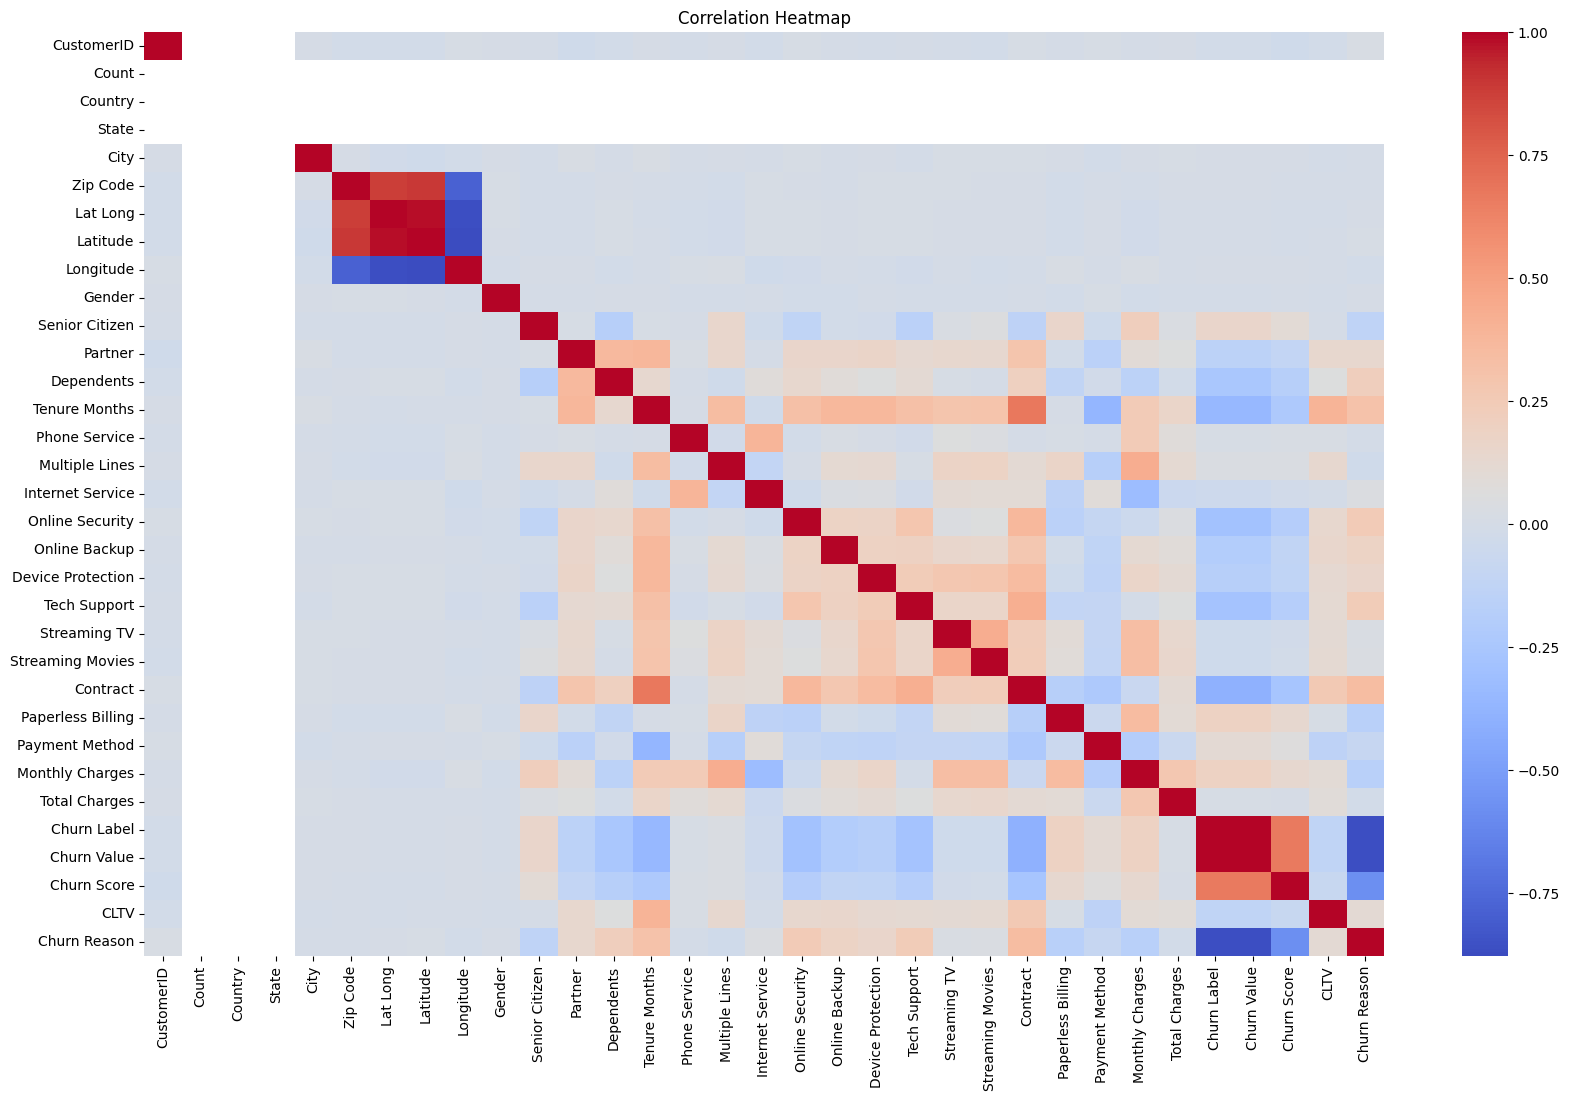

In [204]:
plt.figure(figsize = (20,12))

sns.heatmap(
    df.corr(),
    annot = False,
    cmap = 'coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# FEATURE AND TARGET SEPERATION

In [212]:

X = df[[
    'Gender',
    'Senior Citizen',
    'Partner',
    'Dependents',
    'Tenure Months',
    'Phone Service',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Device Protection',
    'Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Contract',
    'Paperless Billing',
    'Payment Method',
    'Monthly Charges',
    'Total Charges',
    'CLTV'
]]
y = df['Churn Value']



# TRAIN TEST SPLIT

In [216]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

# FEATURE SCALING 

In [219]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# XGBOOST CLASSIFIER

In [222]:
xgb_model = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.03,
    max_depth = 4,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

# MODEL PREDICTION


In [225]:
pred = xgb_model.predict(X_test)

# MODEL ACCURACY

In [228]:
print(
    "Accuracy:",
    accuracy_score(y_test,pred)
)

Accuracy: 0.8026969481902059


# CONFUSION MATRIX

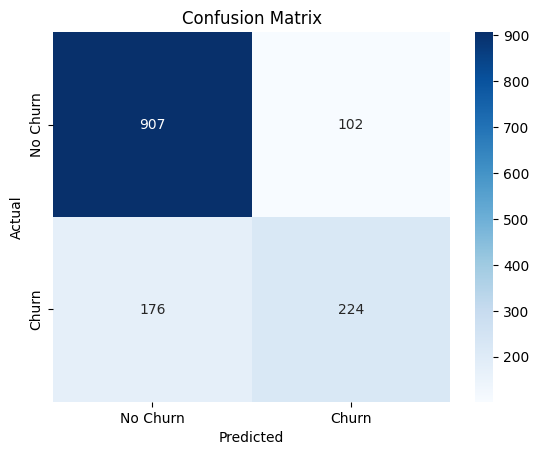

In [231]:
cm = confusion_matrix(y_test,pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# CLASSIFICATION REPORT 

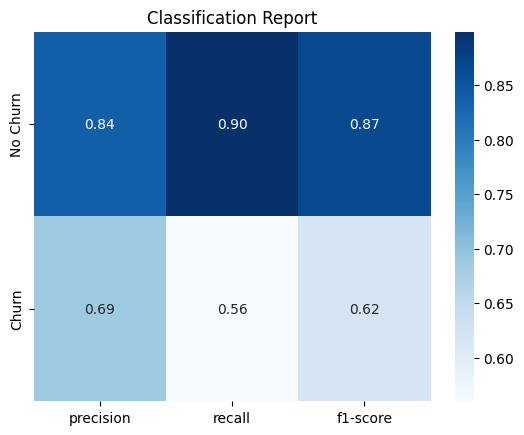

In [239]:
report = classification_report(y_test,
                               pred,
                               target_names=['No Churn', 'Churn'],
                               output_dict=True)

df_report = pd.DataFrame(report).transpose().iloc[:2, :3]

sns.heatmap(df_report, annot=True, fmt='.2f', cmap='Blues')

plt.title('Classification Report')
plt.show()